In [1]:
import numpy as np
from skimage.feature import hog

In [2]:
def load_data(path, isImage):

    with open(path, 'rb') as f:
        data = f.read()
        
    magic = int.from_bytes(data[0:4], 'big')
    num_images = int.from_bytes(data[4:8], 'big')
    rows = int.from_bytes(data[8:12], 'big')
    cols = int.from_bytes(data[12:16], 'big')
    
    if isImage:
        offset = 16  # images have 16-byte header
        arr = np.frombuffer(data, dtype=np.uint8, offset=offset)
        arr = arr.reshape(num_images, rows, cols)
    else:
        offset = 8  # labels have 8-byte header
        arr = np.frombuffer(data, dtype=np.uint8, offset=offset)
        
    return arr


def load_mnist():
    x_train = load_data("../../data/mnist_dataset/train-images-idx3-ubyte", True)
    y_train = load_data("../../data/mnist_dataset/train-labels-idx1-ubyte", False)
    x_test  = load_data("../../data/mnist_dataset/t10k-images-idx3-ubyte", True)
    y_test  = load_data("../../data/mnist_dataset/t10k-labels-idx1-ubyte", False)
    return x_train, y_train, x_test, y_test

In [3]:
x_train, y_train, x_test, y_test = load_mnist()

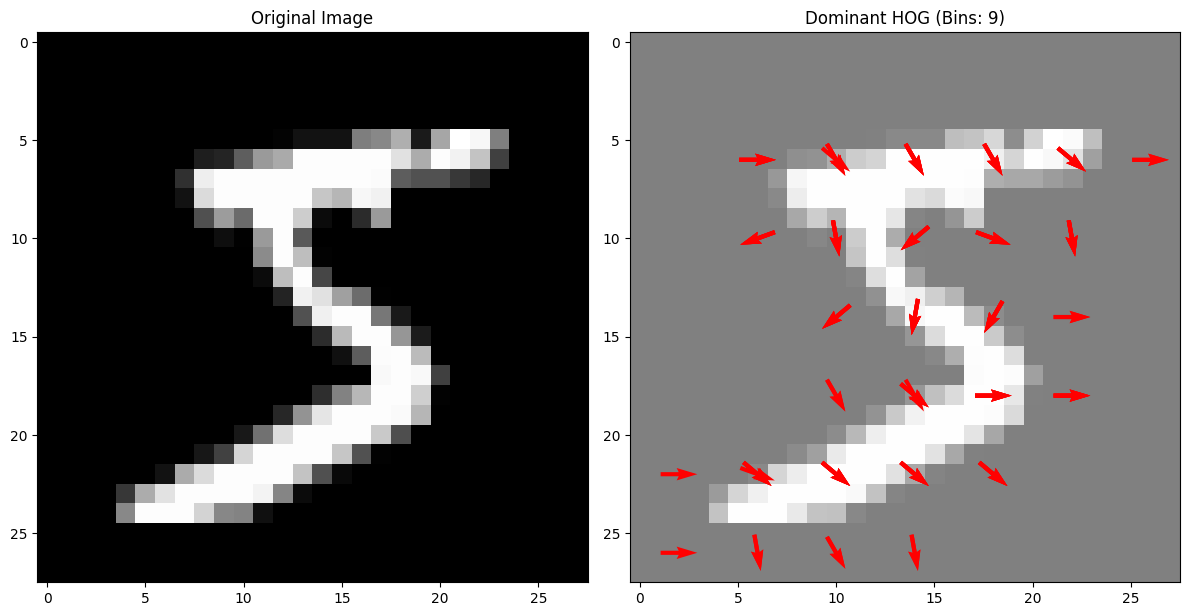

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog

def visualize_hog_dominant_directions(img, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2)):
    # 1. Compute HOG features
    features, hog_image = hog(
        img,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        visualize=True
    )

    # 2. Dynamically calculate the shape for reshaping
    # n_cells = image_size // pixels_per_cell
    n_cells_h = img.shape[0] // pixels_per_cell[0]
    n_cells_w = img.shape[1] // pixels_per_cell[1]

    # n_blocks = n_cells - cells_per_block + 1
    n_blocks_h = n_cells_h - cells_per_block[0] + 1
    n_blocks_w = n_cells_w - cells_per_block[1] + 1

    # 3. Reshape the flat feature vector
    # Shape: (n_blocks_h, n_blocks_w, block_h, block_w, orientations)
    reshaped_features = features.reshape(
        (n_blocks_h, n_blocks_w, cells_per_block[0], cells_per_block[1], orientations)
    )

    # 4. Plotting
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    
    # Left: Original Image
    ax[0].imshow(img, cmap='gray')
    ax[0].set_title("Original Image")
    
    # Right: Dominant Directions Overlay
    ax[1].imshow(img, cmap='gray', alpha=0.5) # Dim the background to see arrows clearly
    
    # Iterate through blocks and cells
    for i in range(n_blocks_h):
        for j in range(n_blocks_w):
            for r in range(cells_per_block[0]):
                for c in range(cells_per_block[1]):
                    bins = reshaped_features[i, j, r, c, :]
                    max_bin = np.argmax(bins)
                    magnitude = bins[max_bin]
                    
                    # Calculate angle
                    angle_deg = max_bin * (180 / orientations)
                    angle_rad = np.deg2rad(angle_deg)
                    
                    # Center of the cell: (Block Index + Cell Index) * Cell Size + Half Cell Size
                    ypos = (i + r) * pixels_per_cell[0] + (pixels_per_cell[0] // 2)
                    xpos = (j + c) * pixels_per_cell[1] + (pixels_per_cell[1] // 2)
                    
                    if magnitude > 0.1:
                        ax[1].quiver(xpos, ypos, np.cos(angle_rad), -np.sin(angle_rad), 
                                     color='red', scale=15, headwidth=3, pivot='middle')

    ax[1].set_title(f"Dominant HOG (Bins: {orientations})")
    plt.tight_layout()
    plt.show()

# Example Usage:
visualize_hog_dominant_directions(x_train[0], orientations=9, pixels_per_cell=(4, 4), cells_per_block=(2, 2))

In [5]:
def softmax(z):
    # subtract row-wise max for numerical stability
    z_stable = z - np.max(z, axis=1, keepdims=True)   # (N, 10)
    exp_z    = np.exp(z_stable)                         # (N, 10)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True) # (N, 10)

In [6]:
def to_one_hot(y, num_classes=10):
    """
    Convert integer labels to one-hot matrix.

    y = [0, 3, 7]  →  [[1,0,0,0,0,0,0,0,0,0],
                        [0,0,0,1,0,0,0,0,0,0],
                        [0,0,0,0,0,0,0,1,0,0]]
    """
    N = y.shape[0]
    Y = np.zeros((N, num_classes))
    Y[np.arange(N), y.astype(int)] = 1.0
    return Y      

In [7]:
def l2_gradient(W, lambda_reg):
    
    grad = lambda_reg * W.copy()
    grad[-1, :] = 0.0                      # don't regularize bias
    return grad                             # (785, 10)

def l2_penalty(W, lambda_reg):

    W_no_bias = W[:-1, :]  # exclude bias row
    return (lambda_reg / 2.0) * np.sum(W_no_bias ** 2)

In [8]:
def train_val_split(X, y, val_fraction=0.1, seed=42):

    rng = np.random.default_rng(seed)
    idx = rng.permutation(X.shape[0])
    cut = int(X.shape[0] * (1 - val_fraction))
    return X[idx[:cut]], y[idx[:cut]], X[idx[cut:]], y[idx[cut:]]

In [22]:
def hog_preprocess(x, orientations=9, pixels_per_cell=(4, 4), cells_per_block=(2, 2)):
    x = np.array([hog(img, orientations=orientations, pixels_per_cell=pixels_per_cell, 
                            cells_per_block=cells_per_block) for img in x])
    return x

In [23]:
x_train_hog = hog_preprocess(x_train, orientations=9, pixels_per_cell=(4, 4), cells_per_block=(2, 2))
x_test_hog  = hog_preprocess(x_test, orientations=9, pixels_per_cell=(4, 4), cells_per_block=(2, 2))

In [ ]:
def softmax_regression(
    X_train_raw,
    y_train_raw,
    num_classes=10,
    batch_size=64,
    learning_rate=0.1,
    lambda_reg=1e-4,
    validation_patience=7,
    epsilon=1e-4,
    max_epochs=200,
    val_fraction=0.1,
    seed=42,
    verbose=True,
):

   
    X_tr, y_tr, X_val, y_val = train_val_split(
        X_train_raw, y_train_raw, val_fraction=val_fraction, seed=seed
    )

    # Standardize HOG features (important for convergence!)
    X_tr_mean = np.mean(X_tr, axis=0, keepdims=True)
    X_tr_std = np.std(X_tr, axis=0, keepdims=True) + 1e-8  # add epsilon to avoid division by zero
    X_tr = (X_tr - X_tr_mean) / X_tr_std
    X_val = (X_val - X_tr_mean) / X_tr_std
    
    print(f"HOG feature dimension: {X_tr.shape}")


    X_tr  = X_tr.reshape(X_tr.shape[0],  -1)    # (N_tr,  784)
    X_val = X_val.reshape(X_val.shape[0], -1)   # (N_val, 784)

    X_tr  = np.hstack([X_tr,  np.ones((X_tr.shape[0],  1))])  # (N_tr,  785)
    X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])  # (N_val, 785)

    D = X_tr.shape[1]   # 785

    Y_tr  = to_one_hot(y_tr,  num_classes)   # (N_tr,  10)
    Y_val = to_one_hot(y_val, num_classes)   # (N_val, 10)

    rng = np.random.default_rng(seed)
    W   = rng.uniform(-0.01, 0.01, size=(D, num_classes))   # (785, 10)

    best_val_loss = float('inf')
    best_W        = W.copy()
    patience_ctr  = 0
    N             = X_tr.shape[0]

    for epoch in range(max_epochs):

        idx       = rng.permutation(N)
        X_shuffled = X_tr[idx]    # (N, 785)
        Y_shuffled = Y_tr[idx]    # (N, 10)

        for start in range(0, N, batch_size):
            end = min(start + batch_size, N)

            X_b = X_shuffled[start:end]   # (B, 785)
            Y_b = Y_shuffled[start:end]   # (B, 10)

            Z     = np.dot(X_b, W)        # (B, 785)·(785,10) = (B, 10)
            Y_hat = softmax(Z)            # (B, 10)


            # dL/dW = X.T(Y_hat - Y_true) / B  
            error = Y_hat - Y_b                    # (B, 10)
            grad  = np.dot(X_b.T, error) / X_b.shape[0]  # (785, 10)
            grad += l2_gradient(W, lambda_reg)     # add L2 gradient

            W -= learning_rate * grad

        # ── validation ────────────────────────────────────────────────────
        Z_val     = np.dot(X_val, W)
        Y_hat_val = softmax(Z_val)
        y_hat_val_clipped = np.clip(Y_hat_val, 1e-15, 1 - 1e-15)  
        val_loss = -np.sum(Y_val * np.log(y_hat_val_clipped)) / Y_val.shape[0]
        val_loss += l2_penalty(W, lambda_reg)


        if verbose:
            print(f"Epoch: {epoch}, Loss:  {val_loss}")

        if val_loss < best_val_loss - epsilon:
            best_val_loss = val_loss
            best_W        = W.copy()
            patience_ctr  = 0
        else:
            patience_ctr += 1

        if patience_ctr >= validation_patience:
            if verbose:
                print(f"Early stopping at epoch {epoch+1}.")
            break

    if verbose and epoch == max_epochs - 1:
        print("Reached maximum epochs.")

    return best_W, X_tr_mean, X_tr_std

In [ ]:
W, X_train_mean, X_train_std = softmax_regression(
    X_train_raw=x_train_hog,
    y_train_raw=y_train,
    num_classes=10,          
    batch_size=32,            
    learning_rate=0.1,       
    lambda_reg=1e-5,         
    validation_patience=15,   
    epsilon=1e-4,           
    max_epochs=200,          
    val_fraction=0.1,       
    seed=42,                 
    verbose=True        
)

HOG feature dimension: (54000, 1296)
Epoch: 0, Loss:  0.16084957678691075
Epoch: 1, Loss:  0.12810687244647895
Epoch: 2, Loss:  0.11411374897601907
Epoch: 3, Loss:  0.10580692007959804
Epoch: 4, Loss:  0.10094637327047831
Epoch: 5, Loss:  0.09634700903628005
Epoch: 6, Loss:  0.09331292967501267
Epoch: 7, Loss:  0.0910655936219514
Epoch: 8, Loss:  0.0893694608557599
Epoch: 9, Loss:  0.08769875924276459
Epoch: 10, Loss:  0.08663516022743821
Epoch: 11, Loss:  0.08523358838618984
Epoch: 12, Loss:  0.08454325650736598
Epoch: 13, Loss:  0.08349937254738837
Epoch: 14, Loss:  0.08332781936481974
Epoch: 15, Loss:  0.08194761194749636
Epoch: 16, Loss:  0.0820787795340772
Epoch: 17, Loss:  0.08121218075729834
Epoch: 18, Loss:  0.08100267792232027
Epoch: 19, Loss:  0.08061346166091929
Epoch: 20, Loss:  0.08047117730093722
Epoch: 21, Loss:  0.07982812876225197
Epoch: 22, Loss:  0.07969482461383287
Epoch: 23, Loss:  0.07933785124662898
Epoch: 24, Loss:  0.07926938775486247
Epoch: 25, Loss:  0.078781

In [ ]:
def predict(X_raw, W):

    X = X_raw.reshape(X_raw.shape[0], -1)
    X = np.hstack([X, np.ones((X.shape[0], 1))])   # add bias

    Z     = X @ W           # (N, 785)·(785,10) = (N, 10)
    proba = softmax(Z)      # (N, 10)
    preds = np.argmax(proba, axis=1)
    return preds, proba

In [ ]:
def evaluate(X_raw, y_true, W, X_train_mean, X_train_std):
    """
    Compute accuracy, per-class precision/recall/F1, and confusion matrix.

    Returns
    -------
    metrics : dict
        'accuracy'  : float
        'precision' : ndarray (10,)
        'recall'    : ndarray (10,)
        'f1'        : ndarray (10,)
        'confusion' : ndarray (10, 10)
    """
    preds, _ = predict(X_raw, W, X_train_mean, X_train_std)
    N        = len(y_true)
    C        = 10

    # confusion matrix  [true, pred]
    cm = np.zeros((C, C), dtype=int)
    for t, p in zip(y_true.astype(int), preds):
        cm[t, p] += 1

    accuracy  = np.trace(cm) / N
    precision = np.zeros(C)
    recall    = np.zeros(C)
    f1        = np.zeros(C)

    for c in range(C):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp

        precision[c] = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall[c]    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1[c]        = (2 * precision[c] * recall[c] /
                        (precision[c] + recall[c])
                        if (precision[c] + recall[c]) > 0 else 0.0)

    return {
        'accuracy' : accuracy,
        'precision': precision,
        'recall'   : recall,
        'f1'       : f1,
        'confusion': cm,
    }

In [ ]:
metrics = evaluate(x_test_hog, y_test, W, X_train_mean, X_train_std)
print(f"Metrics {metrics}")

Metrics {'accuracy': np.float64(0.9807), 'precision': array([0.98375635, 0.98339161, 0.97694524, 0.97841021, 0.98362334,
       0.97984323, 0.99053628, 0.98226601, 0.97427984, 0.97407777]), 'recall': array([0.98877551, 0.99118943, 0.98546512, 0.98712871, 0.97861507,
       0.9809417 , 0.98329854, 0.96984436, 0.97227926, 0.96828543]), 'f1': array([0.98625954, 0.98727512, 0.98118669, 0.98275012, 0.98111281,
       0.98039216, 0.98690414, 0.97601566, 0.97327852, 0.97117296]), 'confusion': array([[ 969,    0,    3,    0,    0,    2,    2,    1,    2,    1],
       [   1, 1125,    1,    1,    1,    1,    2,    2,    1,    0],
       [   3,    2, 1017,    2,    1,    0,    2,    2,    3,    0],
       [   0,    0,    2,  997,    0,    4,    0,    2,    4,    1],
       [   2,    3,    1,    0,  961,    0,    1,    1,    2,   11],
       [   2,    1,    2,    8,    0,  875,    1,    0,    3,    0],
       [   3,    3,    1,    0,    1,    6,  942,    0,    2,    0],
       [   0,    6,    9, 

In [28]:
# compute HOG features for test set and evaluate with W (W was trained on HOG features)                                 # (N, D_no_bias)
X_test_hog = x_test_hog.reshape(x_test_hog.shape[0], -1)
X_test_hog = np.hstack([X_test_hog, np.ones((X_test_hog.shape[0], 1))])  # add bias

Z_test = X_test_hog @ W
proba = softmax(Z_test)
preds = np.argmax(proba, axis=1)

# compute metrics (replicating evaluate)
N = len(y_test)
C = 10
cm = np.zeros((C, C), dtype=int)
for t, p in zip(y_test.astype(int), preds):
    cm[t, p] += 1

accuracy = np.trace(cm) / N
precision = np.zeros(C)
recall = np.zeros(C)
f1 = np.zeros(C)
for c in range(C):
    tp = cm[c, c]
    fp = cm[:, c].sum() - tp
    fn = cm[c, :].sum() - tp
    precision[c] = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall[c] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1[c] = (2 * precision[c] * recall[c] / (precision[c] + recall[c])
             if (precision[c] + recall[c]) > 0 else 0.0)

metrics = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1, 'confusion': cm}
print(f"Metrics accuracy: {metrics['accuracy']:.4f}")
print(f"Per-class precision: {metrics['precision']}")
print(f"Per-class recall:    {metrics['recall']}")
print(f"Per-class F1-score:  {metrics['f1']}")

Metrics accuracy: 0.9807
Per-class precision: [0.98375635 0.98339161 0.97694524 0.97841021 0.98362334 0.97984323
 0.99053628 0.98226601 0.97427984 0.97407777]
Per-class recall:    [0.98877551 0.99118943 0.98546512 0.98712871 0.97861507 0.9809417
 0.98329854 0.96984436 0.97227926 0.96828543]
Per-class F1-score:  [0.98625954 0.98727512 0.98118669 0.98275012 0.98111281 0.98039216
 0.98690414 0.97601566 0.97327852 0.97117296]


In [29]:
def kfold_indices(N, K, seed=42):
    """
    Generate K pairs of (train_indices, val_indices) for K-fold CV.
    """
    rng = np.random.default_rng(seed)
    idx = rng.permutation(N)              # shuffle once

    fold_sizes = np.full(K, N // K)
    fold_sizes[:N % K] += 1              # distribute remainder evenly

    current = 0
    for size in fold_sizes:
        val_idx   = idx[current: current + size]
        train_idx = np.concatenate([idx[:current], idx[current + size:]])
        yield train_idx, val_idx
        current += size


def cross_validate(X, y, params, K=5, seed=42, verbose=False):
    """
    Run K-fold CV for a single hyperparameter combination.

    """
    fold_accs = []

    for fold_idx, (tr_idx, val_idx) in enumerate(kfold_indices(X.shape[0], K, seed)):
        X_tr,  y_tr  = X[tr_idx],  y[tr_idx]
        X_val, y_val = X[val_idx], y[val_idx]

        W = softmax_regression(
            X_tr, y_tr,
            learning_rate    = params['learning_rate'],
            lambda_reg       = params['lambda_reg'],
            batch_size       = params['batch_size'],
            max_epochs       = params.get('max_epochs', 50),
            validation_patience = params.get('patience', 5),
            val_fraction     = 0.1,
            verbose          = False,
            seed             = seed + fold_idx,    # different seed per fold
        )

        metrics  = evaluate(X_val, y_val, W)
        acc      = metrics['accuracy']
        fold_accs.append(acc)

        if verbose:
            print(f"  Fold {fold_idx+1}/{K}  acc={acc:.4f}")

    mean_acc = float(np.mean(fold_accs))
    std_acc  = float(np.std(fold_accs))

    if verbose:
        print(f"  → mean={mean_acc:.4f}  std={std_acc:.4f}")

    return mean_acc, std_acc, fold_accs


In [30]:

import itertools


def grid_search(X, y, param_grid, K=5, seed=42, verbose=True):
    """
    Exhaustive grid search over all combinations in param_grid.

    """
    # build all combinations
    keys   = list(param_grid.keys())
    values = list(param_grid.values())
    combos = list(itertools.product(*values))

    if verbose:
        print(f"Grid search: {len(combos)} combinations x {K} folds "
              f"= {len(combos)*K} training runs\n")

    results = []

    for i, combo in enumerate(combos):
        params = dict(zip(keys, combo))

        if verbose:
            print(f"[{i+1}/{len(combos)}] {params}")

        mean_acc, std_acc, fold_accs = cross_validate(
            X, y, params, K=K, seed=seed, verbose=verbose
        )

        results.append({
            'params'   : params,
            'mean_acc' : mean_acc,
            'std_acc'  : std_acc,
            'fold_accs': fold_accs,
        })

        if verbose:
            print()

    # sort best first
    results.sort(key=lambda r: r['mean_acc'], reverse=True)

    best_params = results[0]['params']

    if verbose:
        print("=" * 60)
        print(f"Best params  : {best_params}")
        print(f"Best CV acc  : {results[0]['mean_acc']:.4f} "
              f"± {results[0]['std_acc']:.4f}")

    return best_params, results


In [31]:
best_params, results = grid_search(
    X=x_train,
    y=y_train,
    param_grid={
        'learning_rate': [0.001, 0.01, 0.05, 0.1],
        'lambda_reg': [1e-5, 1e-4, 1e-3],
        'batch_size': [32, 64, 128]
    },
    K=5,
    verbose=True
)

print(f"Best hyperparameters: {best_params}")

Grid search: 36 combinations x 5 folds = 180 training runs

[1/36] {'learning_rate': 0.001, 'lambda_reg': 1e-05, 'batch_size': 32}
HOG feature dimension: (43200, 28, 28)
  Fold 1/5  acc=0.8969
HOG feature dimension: (43200, 28, 28)
  Fold 2/5  acc=0.9024
HOG feature dimension: (43200, 28, 28)
  Fold 3/5  acc=0.8927
HOG feature dimension: (43200, 28, 28)
  Fold 4/5  acc=0.8892
HOG feature dimension: (43200, 28, 28)
  Fold 5/5  acc=0.9056
  → mean=0.8974  std=0.0060

[2/36] {'learning_rate': 0.001, 'lambda_reg': 1e-05, 'batch_size': 64}
HOG feature dimension: (43200, 28, 28)
  Fold 1/5  acc=0.9024
HOG feature dimension: (43200, 28, 28)
  Fold 2/5  acc=0.8980
HOG feature dimension: (43200, 28, 28)
  Fold 3/5  acc=0.8995
HOG feature dimension: (43200, 28, 28)
  Fold 4/5  acc=0.8914
HOG feature dimension: (43200, 28, 28)


KeyboardInterrupt: 